# Beginner Data Visualization Workshop

Welcome! In this series we will explore Citi Bike usage patterns in NYC and end with a small interactive dashboard.

In [ ]:
from pathlib import Path
import sys

BASE_DIR = Path.cwd()
if (BASE_DIR / "viz-workshop").exists():
    BASE_DIR = BASE_DIR / "viz-workshop"
elif (BASE_DIR / "notebooks").exists():
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR / "../../src"))

from data_prep import load_or_create_dataset, get_paths, print_environment_hint

print_environment_hint()
paths = get_paths(BASE_DIR)



Running locally. Paths are relative to the project folder.


In [12]:
df = load_or_create_dataset(base_dir=BASE_DIR)
print(df.shape)
df.head()

(200000, 15)


,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,rideable_type,member_casual,duration_min,date,hour,day_of_week,day_name
0,2025-12-13 07:43:49.556,2025-12-13 07:51:15.294,Washington St & Laight St,River Ter & Warren St,40.722310,-74.010600,40.717599,-74.015880,classic_bike,member,7.428967,2025-12-13,7,5,Saturday
1,2025-12-21 13:57:34.955,2025-12-21 14:08:36.049,E 7 St & Ave B,1 Ave & E 44 St,40.725129,-73.981317,40.750020,-73.969053,electric_bike,member,11.018233,2025-12-21,13,6,Sunday
2,2025-12-01 17:35:35.005,2025-12-01 17:59:39.517,Queens Plaza North & Crescent St,34 Ave & 74 St,40.751102,-73.940737,40.752970,-73.892360,classic_bike,member,24.075200,2025-12-01,17,0,Monday
3,2025-12-02 23:01:05.402,2025-12-02 23:04:00.373,Metropolitan Ave & Meeker Ave,N 6 St & Bedford Ave,40.714133,-73.952344,40.717452,-73.958509,electric_bike,member,2.916183,2025-12-02,23,1,Tuesday
4,2025-12-06 16:14:28.161,2025-12-06 16:27:07.386,W 92 St & Broadway,W 76 St & Columbus Ave,40.792100,-73.973900,40.780184,-73.977285,classic_bike,member,12.653750,2025-12-06,16,5,Saturday


## First tiny plot: daily trips

Let's build a minimal line plot. This is deliberately simple so you can see the full pipeline working.


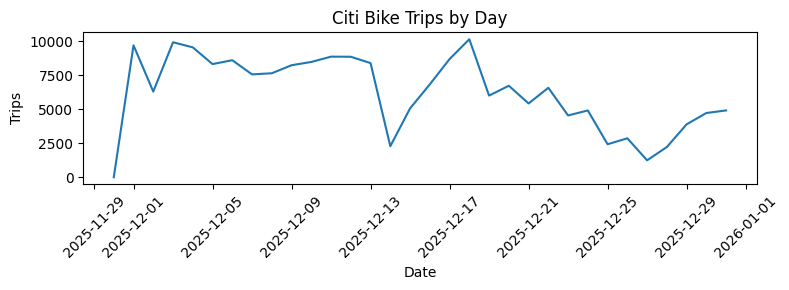

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Daily trip counts
trips_by_day = df.groupby("date").size().reset_index(name="trips")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(trips_by_day["date"], trips_by_day["trips"], color="#1f77b4")
ax.set_title("Citi Bike Trips by Day")
ax.set_xlabel("Date")
ax.set_ylabel("Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Exercise 1
Load the processed dataset and print its shape and column list.

**Check yourself:** you should see a few hundred thousand rows and the columns we will use throughout.


(200000, 15)
Index(['started_at', 'ended_at', 'start_station_name', 'end_station_name',
       'start_lat', 'start_lng', 'end_lat', 'end_lng', 'rideable_type',
       'member_casual', 'duration_min', 'date', 'hour', 'day_of_week',
       'day_name'],
      dtype='object')


## Exercise 2
Recompute `duration_min` from `ended_at - started_at`. Compare it to the existing column.

**Check yourself:** the values should match for a random sample of rows.


0     7.428967
1    11.018233
2    24.075200
3     2.916183
4    12.653750
dtype: float64

How can we make sure that our recalculation was correct?

count    200000.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
dtype: float64